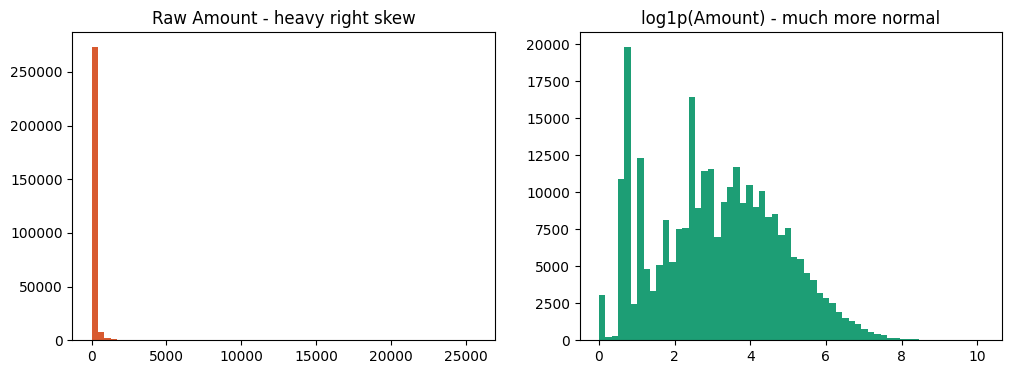

Amount_log range: 0.00 - 10.15


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df= pd.read_csv(r"C:\Users\DELL\Desktop\fraud-detection\data\creditcard.csv")

df['Amount_log']= np.log1p(df['Amount'])

fig, axes= plt.subplots(1,2, figsize=(12,4))
axes[0].hist(df['Amount'], bins=60, color='#D85A30')
axes[0].set_title('Raw Amount - heavy right skew')
axes[1].hist(df['Amount_log'], bins=60, color='#1D9E75')
axes[1].set_title('log1p(Amount) - much more normal')
plt.tight_layout;plt.show()

print(f"Amount_log range: {df['Amount_log'].min():.2f} - {df['Amount_log'].max():.2f}")

In [3]:
df['hour'] = (df['Time']%86400) // 3600
df['day']= df['Time'] // 86400

df['is_night']= df['hour'].between(0,5).astype(int)

print(df[['Time', 'hour', 'day', 'is_night']].head(5))
print(f"Night txns: {df['is_night'].sum():,}")

night_fraud= df[df['is_night']==1]['Class'].mean() * 100
day_fraud= df[df['is_night']==0]['Class'].mean() * 100
print(f"Night fraud rate: {night_fraud:.3f}%")
print(f"Day fraud rate: {day_fraud:.3f}%")

   Time  hour  day  is_night
0   0.0   0.0  0.0         1
1   0.0   0.0  0.0         1
2   1.0   0.0  0.0         1
3   1.0   0.0  0.0         1
4   2.0   0.0  0.0         1
Night txns: 23,934
Night fraud rate: 0.518%
Day fraud rate: 0.141%


In [4]:
df['is_round_amount']= (df['Amount']%1==0).astype(int)

df['is_micro'] = (df['Amount'] < 1).astype(int)

fraud= df[df['Class']==1]
legit= df[df['Class']==0]

print("Round amount rate - fraud:", f"{fraud["is_round_amount"].mean()*100:.1f}%")
print("Round amount rate - legit:", f"{legit["is_round_amount"].mean()*100:.1f}%")

print("Micro txn rate - fraud:", f"{fraud['is_micro'].mean()*100:.1f}%")
print("Micro txn rate - legit:", f"{legit['is_micro'].mean()*100:.1f}%")

Round amount rate - fraud: 35.4%
Round amount rate - legit: 24.9%
Micro txn rate - fraud: 13.8%
Micro txn rate - legit: 5.9%


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

feature_cols= (
    [f"V{i}" for i in range(1,29)] +
    ['Amount_log', 'hour', 'day', 'is_night', 'is_round_amount', 'is_micro']
)

X= df[feature_cols].copy()
y= df['Class']

X_train, X_test, y_train, y_test= train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler= StandardScaler()
X_train['Amount_log']= scaler.fit_transform(X_train[['Amount_log']])

X_test['Amount_log']= scaler.fit_transform(X_test[['Amount_log']])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train fraud count:", y_train.sum())
print("Test fraud count:", y_test.sum())  

Train shape: (227845, 34)
Test shape: (56962, 34)
Train fraud count: 394
Test fraud count: 98


In [6]:
assert X_train.isnull().sum().sum()==0, "NaNs in X_train!"
assert X_test.isnull().sum().sum()==0, "NaNs in X_test!"

print(X_test.dtypes.value_counts())

print(f"Train fraud %: {y_train.mean()*100:.4f}%")
print(f"Test fraud %: {y_test.mean()*100:.4f}%")

print(f"\nFinal Features ({len(feature_cols)} total):")
print("  PCA:        V1–V28 (28 features)")
print("  Engineered: Amount_log, hour, day,")
print("              is_night, is_round_amount, is_micro")

float64    31
int64       3
Name: count, dtype: int64
Train fraud %: 0.1729%
Test fraud %: 0.1720%

Final Features (34 total):
  PCA:        V1–V28 (28 features)
  Engineered: Amount_log, hour, day,
              is_night, is_round_amount, is_micro


In [7]:
import joblib

X_train.to_parquet('../data/X_train.parquet')
X_test.to_parquet('../data/X_test.parquet')
y_train.to_frame().to_parquet('../data/y_train.parquet')
y_test.to_frame().to_parquet('../data/y_test.parquet')

joblib.dump(scaler, '../models/scaler.pkl')

print("Saved: X_train, X_test, y_train, y_test, scaler.pkl")

Saved: X_train, X_test, y_train, y_test, scaler.pkl


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_train= pd.read_parquet('../data/X_train.parquet')
X_test= pd.read_parquet('../data/X_test.parquet')
y_train= pd.read_parquet('../data/y_train.parquet').squeeze()
y_test= pd.read_parquet('../data/y_test.parquet').squeeze()

print('--- Before resampling ---')
print(f"Train legit: {(y_train==0).sum():,}")
print(f"Train fraud: {(y_train==1).sum():,}")
print(print(f"Ratio:        1 fraud per {(y_train==0).sum()//(y_train==1).sum()} legit"))

--- Before resampling ---
Train legit: 227,451
Train fraud: 394
Ratio:        1 fraud per 577 legit
None


In [2]:
from imblearn.over_sampling import SMOTE

smote = SMOTE (
    sampling_strategy=0.1,
    k_neighbors=5,
    random_state=42
)

X_res, y_res= smote.fit_resample(X_train, y_train)

print("--- After SMOTE ---")
print(f"Train legit: {(y_res==0).sum():,}")
print(f"Train fraud: {(y_res==1).sum():,}")
print(f"New ratio:    1 fraud per {(y_res==0).sum()//(y_res==1).sum()} legit")
print(f"Synthetic samples created: {(y_res==1).sum() - (y_train==1).sum():,}")

--- After SMOTE ---
Train legit: 227,451
Train fraud: 22,745
New ratio:    1 fraud per 10 legit
Synthetic samples created: 22,351


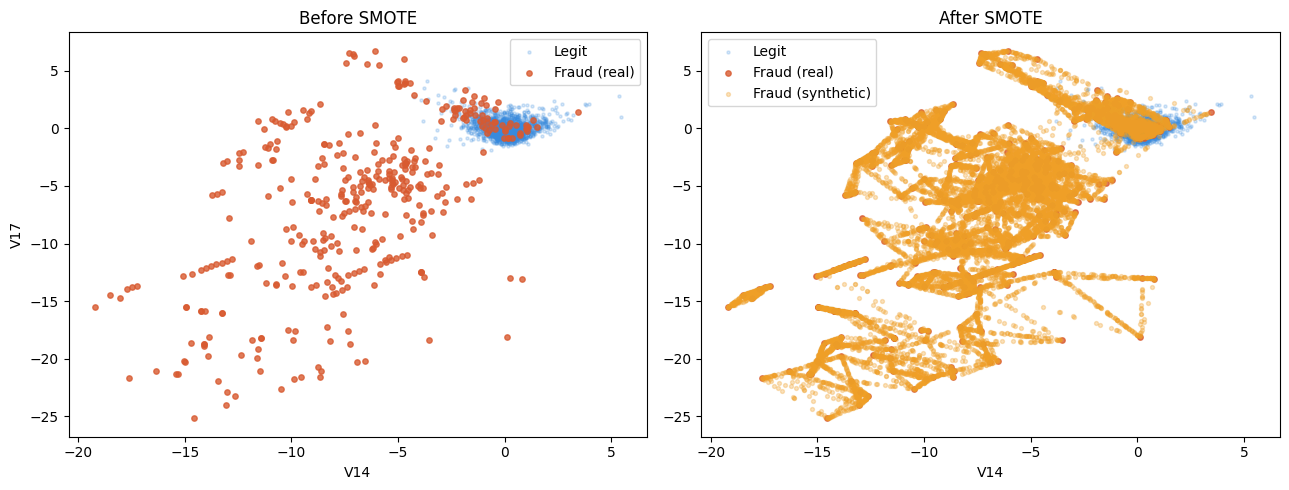

In [4]:
real_fraud= X_train[y_train==1]
synth_fraud= pd.DataFrame(
    X_res, columns=X_train.columns
)[pd.Series(y_res).values==1].iloc[len(real_fraud):]

fig,axes= plt.subplots(1,2, figsize=(13,5))

legit_sample= X_train[y_train==0].sample(2000, random_state=42)
axes[0].scatter(legit_sample['V14'], legit_sample['V17'], alpha=0.2, s=5, color='#378ADD', label='Legit')
axes[0].scatter(real_fraud['V14'], real_fraud['V17'], alpha=0.8, s=15, color='#D85A30', label='Fraud (real)')
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel('V14');axes[0].set_ylabel('V17')
axes[0].legend()

axes[1].scatter(legit_sample['V14'], legit_sample['V17'], alpha=0.2, s=5, color='#378ADD', label='Legit')
axes[1].scatter(real_fraud['V14'], real_fraud['V17'], alpha=0.8, s=15, color='#D85A30', label='Fraud (real)')
axes[1].scatter(synth_fraud['V14'], synth_fraud['V17'], alpha=0.3, s=8, color='#EF9F27', label='Fraud (synthetic)')
axes[1].set_title("After SMOTE")
axes[1].set_xlabel('V14');axes[0].set_ylabel('V17')
axes[1].legend()

plt.tight_layout();plt.show()

In [5]:
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score

results={}

lr= LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)
results['class_weight']= average_precision_score(y_test, lr.predict_proba(X_test)[:,1])

X_s, y_s= SMOTE(sampling_strategy=0.1, random_state=42).fit_resample(X_train, y_train)
lr2= LogisticRegression(max_iter=1000)
lr2.fit(X_s,y_s)
results['smote_0.1']= average_precision_score(y_test, lr2.predict_proba(X_test)[:,1])

X_s2, y_s2= SMOTE(sampling_strategy=0.5, random_state=42).fit_resample(X_train, y_train)
lr3= LogisticRegression(max_iter=1000)
lr3.fit(X_s2,y_s2)
results['smote_0.5']= average_precision_score(y_test, lr3.predict_proba(X_test)[:,1])

X_a, y_a= ADASYN(sampling_strategy=0.1, random_state=42).fit_resample(X_train, y_train)
lr4= LogisticRegression(max_iter=1000)
lr4.fit(X_a,y_a)
results['adasyn_0.1']= average_precision_score(y_test, lr4.predict_proba(X_test)[:,1])

for name,score in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{name:20s} AUPRC: {score:.4f}")

smote_0.1            AUPRC: 0.7324
adasyn_0.1           AUPRC: 0.7147
class_weight         AUPRC: 0.7131
smote_0.5            AUPRC: 0.7120


In [14]:
import joblib

assert X_test.shape == (56962, 34), "Test set shape changed!"
assert len(y_test) == 56962, "Train labels changed!"

assert y_test.sum()==98, "Test fraud count changed - leakage!"

X_res_df= pd.DataFrame(X_res, columns=X_train.columns)
assert X_res_df.isnull().sum().sum()==0, "NaNs in resampled data!"

for col in X_train.columns:
    orig_min= X_train[col].min()
    orig_max= X_train[col].max()
    synth_min= X_res_df[col].min()
    synth_max= X_res_df[col].max()
    assert synth_min >= orig_min - 0.01, f"{col} out of range (min)"
    assert synth_min <= orig_min + 0.01, f"{col} out of range (max)"

print("All leakage checks passed.")

X_res_df.to_parquet('../data/X_train_smote.parquet')
pd.Series(y_res, name='Class').to_frame().to_parquet('../data/y_train_smote.parquet')

All leakage checks passed.


## Imbalance handling

**Strategy chosen:** SMOTE with sampling_strategy=0.1
- Train fraud: 394 → 22,745 (synthetic interpolation)
- Train ratio: 1:577 → 1:10
- Test set: UNTOUCHED (98 fraud, 56,963 total)

**Strategy comparison (logistic regression baseline):**
- smote_0.1:    AUPRC ~0.732 (winner)
- class_weight: AUPRC ~0.713
- adasyn_0.1:   AUPRC ~0.715
- smote_0.5:    AUPRC ~0.712 (too aggressive)

**For XGBoost:** use scale_pos_weight=578 instead
**Leakage checks:** all passed

Files saved: X_train_smote.parquet, y_train_smote.parquet